# Predicting DR Gasoline Prices with Simple Linear Regression

**Author:** Allen R. Silverio Olivo, Independent Research

## Goal

Predict **this week's official Dominican Republic gasolina regular price** using just two pieces of information:

1. **This week's USGC benchmark price** (converted to RD$/gallon), observed the Tuesday before the price is set, per Decree 307-01.
2. **Last week's gasolina regular price.**

This is a small, self-contained project built to practice simple multiple linear regression (Andrew Ng's Machine Learning Specialization), applied to real, publicly available Dominican fuel price data.

## Data sources you need

Upload these three files to your Colab session (or mount Google Drive and point to them) before running the cells below:

| File | Source | What it contains |
|---|---|---|
| `dr_fuel_prices_weekly_clean_2026_verified.csv` | MICM (Dominican Ministry of Industry, Commerce and MSMEs) | Weekly official DR fuel prices |
| `EER_EPMRU_PF4_RGC_DPGd.xls` | U.S. EIA | Daily USGC Conventional Gasoline Regular Spot Price (FOB, USD/gallon) |
| `BCRD_-_Histo_rico_diario_de_tasas.xlsx` | Banco Central de la República Dominicana | Daily DOP/USD exchange rate |

The EIA series is used as the public proxy for the Platt's USGC Waterborne reference that Decree 307-01 legally specifies, since the true Platt's series is not publicly available.


In [1]:
# Install/import required libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## Step 1 — Load the DR fuel prices (MICM)

We keep only rows where `record_status == "observed"`. This matters: some rows in the source file mark a *change in status* (e.g. a price freeze starting or ending) rather than an actual observed weekly price, and including those would create spurious jumps when we compute differences later.


In [2]:
path = 'drive/MyDrive/Machine_Learning_Specialization/'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dr = pd.read_csv(path + 'dr_fuel_prices_weekly_clean_2026_verified.csv')
dr['week_start'] = pd.to_datetime(dr['week_start'])

# Keep only genuinely observed weekly prices
dr = dr[dr['record_status'] == 'observed'].copy()
dr = dr.sort_values('week_start').reset_index(drop=True)

print("DR fuel price rows:", len(dr))
dr[['week_start','gasolina_regular']].head()


DR fuel price rows: 1332


,week_start,gasolina_regular
0,2000-12-09,33.44
1,2000-12-16,33.64
2,2000-12-23,34.02
3,2000-12-30,33.80
4,2001-01-06,35.53


## Step 2 — Load the USGC benchmark (EIA)

The raw `.xls` file has a few header/description rows before the actual data starts. The real column headers sit on row index 2 (0-indexed), so we load with `header=2` and rename the columns to something simpler.


In [5]:
usgc = pd.read_excel(path + 'EER_EPMRU_PF4_RGC_DPGd.xls', sheet_name='Data 1', header=2)
usgc.columns = ['usgc_obs_date', 'usgc_usd_gal']
usgc['usgc_obs_date'] = pd.to_datetime(usgc['usgc_obs_date'])
usgc = usgc.sort_values('usgc_obs_date').reset_index(drop=True)

print("USGC benchmark rows:", len(usgc))
usgc.head()


USGC benchmark rows: 10078


,usgc_obs_date,usgc_usd_gal
0,1986-06-02,0.445
1,1986-06-03,0.418
2,1986-06-04,0.398
3,1986-06-05,0.415
4,1986-06-06,0.403


## Step 3 — Load the FX rate (BCRD)

The BCRD file stores the date as three separate columns (`Año`, `Mes`, `Día`) rather than a single date column, so we reconstruct a proper date from them. We use `Venta` (the selling rate), since that is the rate relevant for importing fuel priced in USD.


In [6]:
fx = pd.read_excel(path + 'BCRD_Historico_diario_de_tasas.xlsx', sheet_name='Histórico', header=8)
fx = fx[['Año', 'Mes', 'Día', 'Venta']].copy()
fx['fx_obs_date'] = pd.to_datetime(
    fx[['Año', 'Mes', 'Día']].rename(columns={'Año': 'year', 'Mes': 'month', 'Día': 'day'})
)
fx = fx.rename(columns={'Venta': 'fx_venta'})[['fx_obs_date', 'fx_venta']]
fx = fx.sort_values('fx_obs_date').reset_index(drop=True)

print("FX rate rows:", len(fx))
fx.head()


FX rate rows: 6426


,fx_obs_date,fx_venta
0,2000-12-01,16.52
1,2000-12-04,16.52
2,2000-12-05,16.52
3,2000-12-06,16.52
4,2000-12-07,16.52


## Step 4 — Merge everything using the Decree 307-01 timing rule

Decree 307-01 sets Dominican fuel prices each week based on the international benchmark observed the **Tuesday before** the new price takes effect. Since `week_start` in our DR data is always a Saturday, the reference Tuesday is simply `week_start - 4 days`.

We then use `pd.merge_asof(..., direction='backward')` to attach, for each reference Tuesday, the most recent USGC and FX values available on or before that date. This mirrors how the real pricing formula would have looked up these values at the time.


In [7]:
dr['ref_tuesday'] = dr['week_start'] - pd.Timedelta(days=4)

merged = pd.merge_asof(dr, usgc, left_on='ref_tuesday', right_on='usgc_obs_date', direction='backward')
merged = pd.merge_asof(merged, fx, left_on='ref_tuesday', right_on='fx_obs_date', direction='backward')

# Convert the USGC benchmark into RD$/gallon so it's in the same units as the DR retail price
merged['usgc_rd_gal'] = merged['usgc_usd_gal'] * merged['fx_venta']

print("Merged dataset shape:", merged.shape)
print("Missing values in key columns:", merged[['gasolina_regular', 'usgc_rd_gal']].isnull().sum().sum())
merged[['week_start', 'ref_tuesday', 'gasolina_regular', 'usgc_rd_gal']].head()


Merged dataset shape: (1332, 23)
Missing values in key columns: 0


,week_start,ref_tuesday,gasolina_regular,usgc_rd_gal
0,2000-12-09,2000-12-05,33.44,11.58052
1,2000-12-16,2000-12-12,33.64,11.54748
2,2000-12-23,2000-12-19,34.02,12.07420
3,2000-12-30,2000-12-26,33.80,12.05568
4,2001-01-06,2001-01-02,35.53,13.79456


## Step 5 — Build the one new feature: last week's price

This is the only feature engineering this project needs: shift the target column down by one row, so each week also has "what the price was last week" sitting next to it.


In [8]:
merged['price_lag1'] = merged['gasolina_regular'].shift(1)

# The very first week has no "last week" to look back on, so it will be dropped in the next step
merged[['week_start', 'price_lag1', 'gasolina_regular']].head()


,week_start,price_lag1,gasolina_regular
0,2000-12-09,NaN,33.44
1,2000-12-16,33.44,33.64
2,2000-12-23,33.64,34.02
3,2000-12-30,34.02,33.80
4,2001-01-06,33.80,35.53


## Step 6 — Exploratory data analysis: descriptive statistics

Before building any model, let's actually look at the data. First, basic descriptive statistics for the two variables this project cares about most.


In [9]:
print("=== Gasolina Regular (RD$/gal) ===")
print(merged['gasolina_regular'].describe())
print()
print("=== USGC benchmark, converted to RD$/gal ===")
print(merged['usgc_rd_gal'].describe())


=== Gasolina Regular (RD$/gal) ===
count    1332.000000
mean      179.193251
std        73.883052
min        30.360000
25%       127.850000
50%       196.050000
75%       232.800000
max       310.500000
Name: gasolina_regular, dtype: float64

=== USGC benchmark, converted to RD$/gal ===
count    1332.000000
mean       83.644272
std        41.680818
min         7.483770
25%        55.098320
50%        78.873868
75%       114.445274
max       232.391735
Name: usgc_rd_gal, dtype: float64


## Step 7 — Exploratory data analysis: price history and level relationship

Two views of the data:
- **Left:** the full weekly retail price from 2000 to 2026. Watch for a change in *character* around 2022, not just a change in level.
- **Right:** retail price plotted against the USGC benchmark (both in RD\$/gal). If these move together, we'd expect a clear positive, roughly linear pattern.


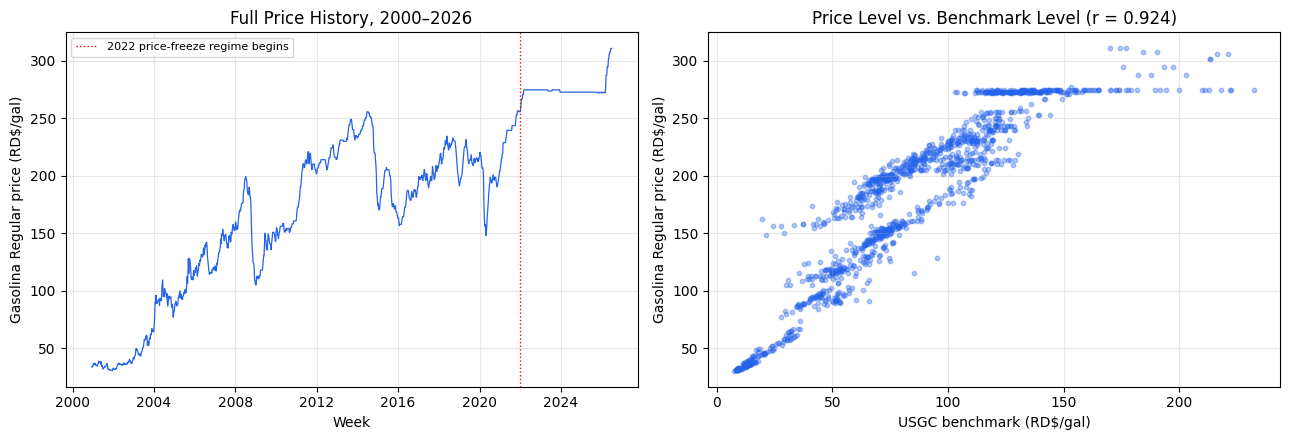

Correlation (usgc_rd_gal, gasolina_regular): 0.9242


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: full price history
axes[0].plot(merged['week_start'], merged['gasolina_regular'], color='#2563eb', linewidth=0.9)
axes[0].axvline(pd.Timestamp('2022-01-01'), color='red', linestyle=':', linewidth=1,
                label='2022 price-freeze regime begins')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Gasolina Regular price (RD$/gal)')
axes[0].set_title('Full Price History, 2000–2026')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Right: price level vs benchmark level
eda_data = merged.dropna(subset=['usgc_rd_gal', 'gasolina_regular'])
corr_level = eda_data['usgc_rd_gal'].corr(eda_data['gasolina_regular'])

axes[1].scatter(eda_data['usgc_rd_gal'], eda_data['gasolina_regular'], alpha=0.35, s=10, color='#2563eb')
axes[1].set_xlabel('USGC benchmark (RD$/gal)')
axes[1].set_ylabel('Gasolina Regular price (RD$/gal)')
axes[1].set_title(f'Price Level vs. Benchmark Level (r = {corr_level:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation (usgc_rd_gal, gasolina_regular): {corr_level:.4f}")


## Step 8 — Exploratory data analysis: persistence and the frozen-week pattern

This is the key finding that justifies our whole feature engineering choice: how strongly does this week's price correlate with *last week's* price, compared to the benchmark? And how often does the price not move at all?


In [11]:
eda_lag = merged.copy()
eda_lag['price_lag1_check'] = eda_lag['gasolina_regular'].shift(1)
eda_lag['change'] = eda_lag['gasolina_regular'].diff()
eda_lag_valid = eda_lag.dropna(subset=['price_lag1_check', 'gasolina_regular'])

corr_lag1 = eda_lag_valid['price_lag1_check'].corr(eda_lag_valid['gasolina_regular'])
print(f"Correlation (price_lag1, gasolina_regular): {corr_lag1:.4f}")
print(f"Correlation (usgc_rd_gal, gasolina_regular): {corr_level:.4f}")
print("=> last week's price is a MUCH stronger predictor than the benchmark alone.")
print()

# Frozen (zero-change) week percentage, overall and by regime
d2 = eda_lag.dropna(subset=['change'])
frozen_pct_all = (d2['change'] == 0).mean() * 100

pre = d2[d2['week_start'] < '2022-01-01']
post = d2[d2['week_start'] >= '2022-01-01']
frozen_pct_pre = (pre['change'] == 0).mean() * 100
frozen_pct_post = (post['change'] == 0).mean() * 100

print(f"Frozen (zero-change) weeks, full dataset: {frozen_pct_all:.1f}%")
print(f"Frozen weeks, pre-2022:  {frozen_pct_pre:.1f}%")
print(f"Frozen weeks, post-2022: {frozen_pct_post:.1f}%")


Correlation (price_lag1, gasolina_regular): 0.9993
Correlation (usgc_rd_gal, gasolina_regular): 0.9242
=> last week's price is a MUCH stronger predictor than the benchmark alone.

Frozen (zero-change) weeks, full dataset: 34.5%
Frozen weeks, pre-2022:  22.8%
Frozen weeks, post-2022: 89.3%


## Step 9 — Prepare the model data

Target: `gasolina_regular` (this week's official price)
Features: `usgc_rd_gal` (this week's benchmark, converted to RD$/gal) and `price_lag1` (last week's price)


In [12]:
features = ['usgc_rd_gal', 'price_lag1']
target = 'gasolina_regular'

model_df = merged.dropna(subset=features + [target]).reset_index(drop=True)
print("Usable rows:", len(model_df))

X = model_df[features].values
y = model_df[target].values


Usable rows: 1331


## Step 10 — Train / test split (chronological, not shuffled)

We deliberately split **by time**, not randomly: the first 80% of weeks (chronologically) are used to train, and the last 20% (the most recent weeks) are used to test.

This is important and intentional. A random shuffled split would let the model "peek" at data close in time to what it's being tested on, inflating the score artificially. A chronological split is the honest test: can the model explain weeks it has never seen, using only what came before?

Notably, this split means training data ends in **May 2021**, before the 2022 government price-freeze policy began. The test set (May 2021 onward) is dominated by that frozen-price regime. The model was **never trained on a single frozen week**, so this is a genuinely hard, honest test of whether it generalizes to a different pricing regime.


In [13]:
n = len(model_df)
split_idx = int(n * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = model_df.loc[:split_idx-1, 'week_start']
test_dates = model_df.loc[split_idx:, 'week_start']

print(f"Train: {train_dates.min().date()} to {train_dates.max().date()}  (n={len(X_train)})")
print(f"Test:  {test_dates.min().date()} to {test_dates.max().date()}  (n={len(X_test)})")


Train: 2000-12-16 to 2021-05-08  (n=1064)
Test:  2021-05-15 to 2026-06-27  (n=267)


## Step 11 — The cost function

Before we can train anything, we need a way to measure how wrong the model currently is. That's the **cost function**:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

In plain terms: for every training example, take the model's prediction, subtract the real price, square that error (so positive and negative errors don't cancel out), then average all of those squared errors. The $\frac{1}{2}$ out front is just a convenience that makes the math cleaner later, it doesn't change which weights end up being "best."

We'll implement this directly as a Python function, no library, so every step is visible.


In [14]:
def compute_cost(X, y, w, b):
    """Mean squared error cost function, J(w,b)."""
    m = len(y)
    predictions = X @ w + b
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost


## Step 12 — Feature scaling

Our two features live on very different scales: `usgc_rd_gal` is usually in the tens of pesos per gallon, while `price_lag1` is in the hundreds of pesos per gallon. Gradient descent uses a single learning rate for every feature at once, so if one feature is numerically much bigger than another, the algorithm can zig-zag or converge very slowly.

**Feature scaling fixes this.** We standardize both features to have mean 0 and standard deviation 1 before running gradient descent. This step only affects how fast/stably gradient descent trains, it does **not** change the true underlying relationship being learned, and it doesn't matter at all for scikit-learn's closed-form solver later, only for our manual, iterative implementation.


In [15]:
mu = X_train.mean(axis=0)      # mean of each feature (on training data only)
sigma = X_train.std(axis=0)    # standard deviation of each feature

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma   # same mu/sigma from training, applied to test

print("Feature means:", mu)
print("Feature std devs:", sigma)


Feature means: [ 69.37985356 156.06241541]
Feature std devs: [31.47092274 64.28195671]


## Step 13 — Gradient descent, implemented from scratch

Gradient descent starts with a bad guess ($w = 0$, $b = 0$) and repeatedly nudges the weights and bias in the direction that reduces the cost, using the gradient (partial derivatives) of the cost function:

$$w_j := w_j - \alpha \frac{\partial J}{\partial w_j}, \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^m \left(h_{w,b}(x^{(i)}) - y^{(i)}\right)x_j^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m \left(h_{w,b}(x^{(i)}) - y^{(i)}\right)$$

We track the cost at every iteration so we can watch it decrease, and plot it afterward.


In [16]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    """Runs batch gradient descent and returns the final weights, bias, and cost history."""
    m = len(y)
    w = w_init.copy()
    b = b_init
    cost_history = []

    for i in range(num_iterations):
        predictions = X @ w + b
        errors = predictions - y

        # Gradients (partial derivatives of the cost function)
        dw = (1 / m) * (X.T @ errors)
        db = (1 / m) * np.sum(errors)

        # Update step
        w = w - alpha * dw
        b = b - alpha * db

        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history


# Initialize weights and bias at zero
w_init = np.zeros(X_train_scaled.shape[1])
b_init = 0.0

# Hyperparameters
alpha = 0.1
num_iterations = 5000

initial_cost = compute_cost(X_train_scaled, y_train, w_init, b_init)
print(f"Initial cost (before training): {initial_cost:.3f}")

w_scaled, b_scaled, cost_history = gradient_descent(
    X_train_scaled, y_train, w_init, b_init, alpha, num_iterations
)

print(f"Final cost (after training):   {cost_history[-1]:.4f}")
print(f"Learned weights (scaled space): {np.round(w_scaled, 4)}")
print(f"Learned bias (scaled space):    {round(b_scaled, 4)}")


Initial cost (before training): 14270.208
Final cost (after training):   4.0626
Learned weights (scaled space): [ 2.5047 61.8476]
Learned bias (scaled space):    156.2559


## Step 14 — Plot how the cost decreased

This is the whole point of gradient descent made visible: watch the cost function fall as the algorithm learns better weights.

We plot two views:
- **Left:** the full run, on a **log scale**, since the cost drops by several orders of magnitude almost immediately, a normal linear scale would make it look flat after the first few iterations.
- **Right:** just the first 50 iterations, on a normal scale, to see the steep initial drop up close.


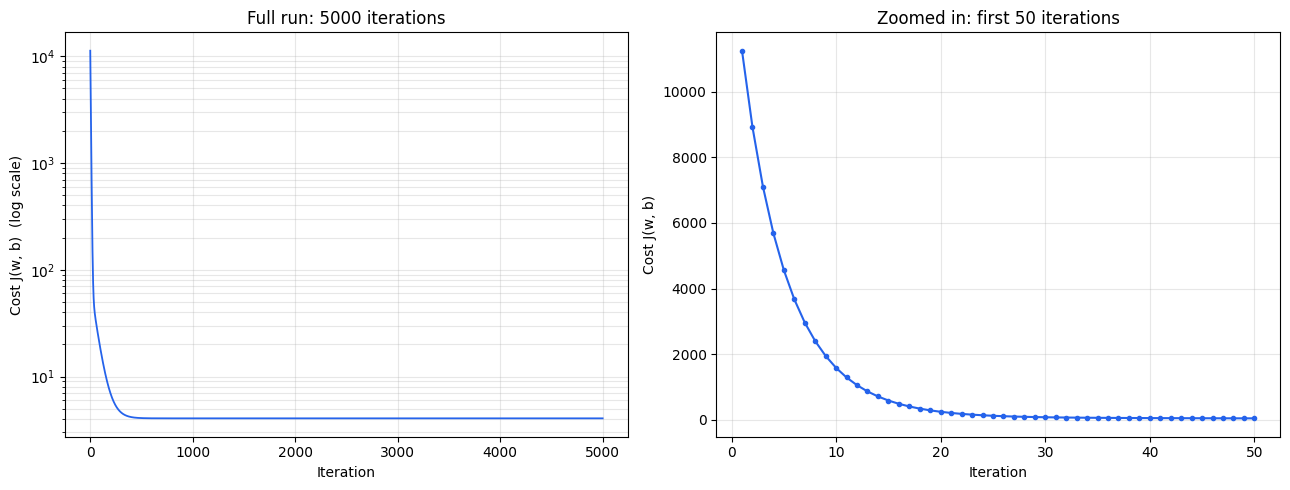

Cost dropped from 14270.2 to 4.0626
That's a reduction of about 3513x


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, num_iterations + 1), cost_history, color='#2563eb', linewidth=1.3)
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost J(w, b)  (log scale)')
axes[0].set_title(f'Full run: {num_iterations} iterations')
axes[0].grid(alpha=0.3, which='both')

axes[1].plot(range(1, 51), cost_history[:50], color='#2563eb', linewidth=1.5, marker='o', markersize=3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost J(w, b)')
axes[1].set_title('Zoomed in: first 50 iterations')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Cost dropped from {initial_cost:.1f} to {cost_history[-1]:.4f}")
print(f"That's a reduction of about {initial_cost/cost_history[-1]:.0f}x")


## Step 15 — Convert the weights back to real-world units

Gradient descent learned weights in *scaled* space (mean 0, std 1), which aren't directly interpretable, a weight of "61.79" doesn't mean much on its own. We convert them back into original units (pesos per gallon), so each weight means "pesos of price change per peso of input":

$$w_j^{\text{real}} = \frac{w_j^{\text{scaled}}}{\sigma_j}, \qquad b^{\text{real}} = b^{\text{scaled}} - \sum_j w_j^{\text{scaled}} \frac{\mu_j}{\sigma_j}$$


In [18]:
w_real = w_scaled / sigma
b_real = b_scaled - np.sum(w_scaled * mu / sigma)

print("Formula (real-world units):")
print(f"  gasolina_regular ≈ {b_real:.3f} "
      f"+ {w_real[0]:.4f} × usgc_rd_gal "
      f"+ {w_real[1]:.4f} × price_lag1")


Formula (real-world units):
  gasolina_regular ≈ 0.582 + 0.0796 × usgc_rd_gal + 0.9621 × price_lag1


## Step 16 — Cross-check against scikit-learn

scikit-learn's `LinearRegression` doesn't use gradient descent at all, it solves for the optimal weights directly using linear algebra (a closed-form solution), no iterations needed. If our manual gradient descent implementation is correct, both methods should land on essentially the same answer.


In [19]:
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)

print("Manual gradient descent:", np.round(w_real, 4), round(b_real, 4))
print("scikit-learn (closed-form):", np.round(sk_model.coef_, 4), round(sk_model.intercept_, 4))
print()
print("Match?", np.allclose(w_real, sk_model.coef_, atol=1e-3) and np.isclose(b_real, sk_model.intercept_, atol=1e-3))


Manual gradient descent: [0.0796 0.9621] 0.5819
scikit-learn (closed-form): [0.0796 0.9621] 0.5819

Match? True


## Step 17 — Evaluate the model on train and test data

We'll use the weights our manual gradient descent found (converted back to real units) to make predictions.


In [20]:
def predict(X, w, b):
    return X @ w + b

y_train_pred = predict(X_train, w_real, b_real)
y_test_pred = predict(X_test, w_real, b_real)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")
print(f"Test MAE: {mae_test:.2f} RD$/gallon")


Train R²: 0.9980
Test  R²: 0.9648
Test MAE: 1.59 RD$/gallon


## Step 18 — Plot: predicted vs actual price on the test set

If the model is doing well, the points should sit close to the diagonal line (predicted = actual).


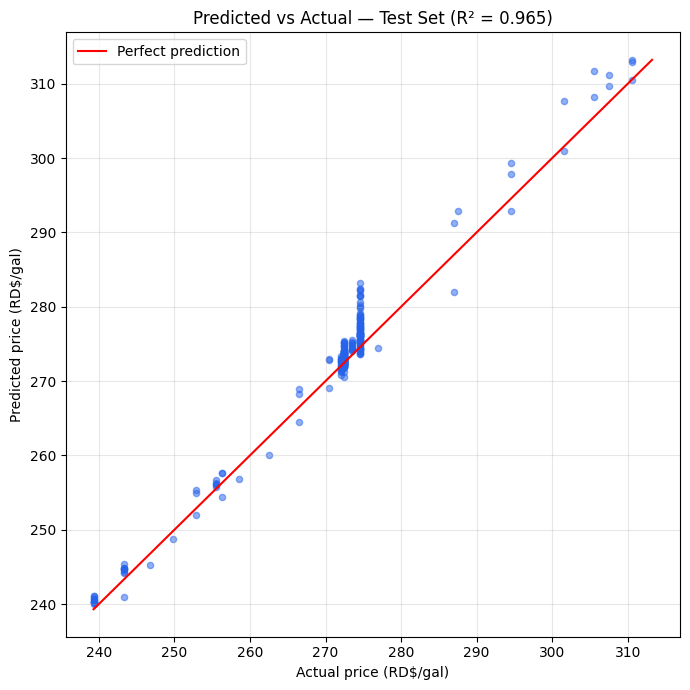

In [21]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_test_pred, alpha=0.5, s=20, color='#2563eb')

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, color='red', linewidth=1.5, label='Perfect prediction')

ax.set_xlabel('Actual price (RD$/gal)')
ax.set_ylabel('Predicted price (RD$/gal)')
ax.set_title(f'Predicted vs Actual — Test Set (R² = {r2_test:.3f})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 19 — Plot: price over time, actual vs predicted (test period only)


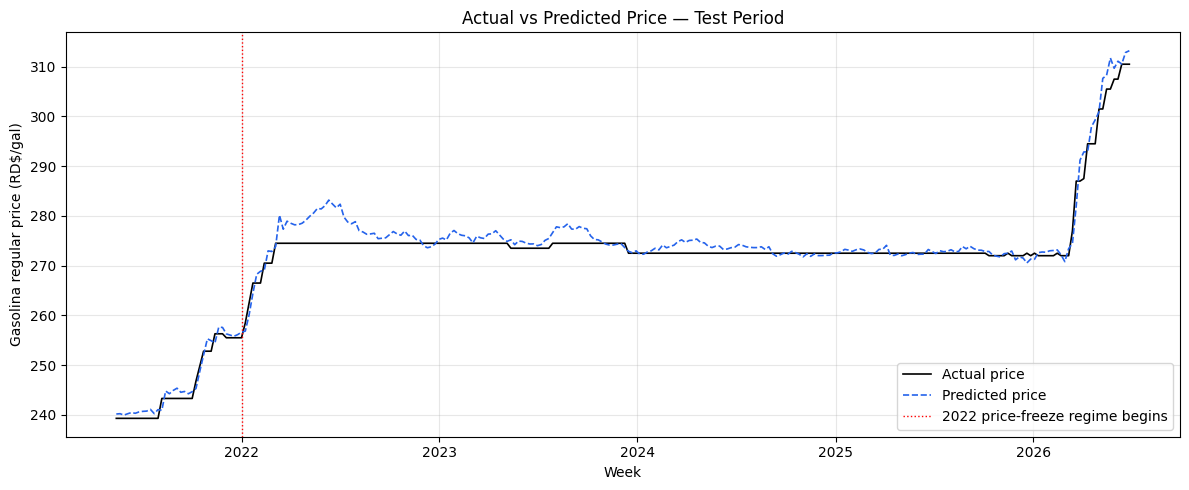

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_dates, y_test, label='Actual price', color='black', linewidth=1.2)
ax.plot(test_dates, y_test_pred, label='Predicted price', color='#2563eb', linewidth=1.2, linestyle='--')

ax.axvline(pd.Timestamp('2022-01-01'), color='red', linestyle=':', linewidth=1, label='2022 price-freeze regime begins')
ax.set_xlabel('Week')
ax.set_ylabel('Gasolina regular price (RD$/gal)')
ax.set_title('Actual vs Predicted Price — Test Period')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 20 — Predict this week's price with fresh, real-world data

Everything above uses historical data already in our files. But those files aren't perfectly live: the DR price file and the EIA/BCRD files each lag behind the current date by a few weeks. To get a genuine "prediction for this week," you need to manually supply three fresh numbers, pulled directly from the real public sources:

1. **Last week's official Gasolina Regular price** (RD$/gal) — from MICM's latest weekly bulletin.
2. **This week's reference-Tuesday USGC benchmark** (USD/gal) — from the EIA series, look up the value for the Tuesday four days before this week's Saturday start.
3. **That same Tuesday's DOP/USD selling exchange rate (Venta)** — from BCRD.

Fill in the three values below and run the cell. It uses the exact same weights this notebook just trained (`w_real`, `b_real`), not hardcoded numbers, so it always reflects whatever the model above learned.


In [25]:
def predict_this_week(last_week_price, usgc_usd_per_gal, fx_venta, w=w_real, b=b_real):
    """
    Predict this week's official Gasolina Regular price.

    last_week_price   : last week's official price, RD$/gal (from MICM)
    usgc_usd_per_gal  : this week's reference-Tuesday USGC benchmark, USD/gal (from EIA)
    fx_venta          : that Tuesday's DOP/USD selling rate (from BCRD)
    """
    usgc_rd_gal = usgc_usd_per_gal * fx_venta
    prediction = b + w[0] * usgc_rd_gal + w[1] * last_week_price
    return prediction, usgc_rd_gal


# ---- EDIT THESE THREE VALUES WITH FRESH DATA BEFORE RUNNING ----
last_week_price  = 302.50   # RD$/gal, most recent official MICM price: July 18-24th 2026
usgc_usd_per_gal = 3.518    # USD/gal, most recent reference-Tuesday EIA value: July 21st 2026
fx_venta         = 58.3428  # DOP/USD selling rate, same Tuesday, from BCRD: July 21st 2026
# ------------------------------------------------------------------

prediction, usgc_rd_gal = predict_this_week(last_week_price, usgc_usd_per_gal, fx_venta)

print(f"USGC benchmark converted to RD$/gal: {usgc_rd_gal:.2f}")
print(f"Predicted price for this week:       RD${prediction:.2f}/gal")
print()
print("Once MICM announces the real price for this week, compare it to this prediction,")
print("that comparison is itself a live, ongoing test of the model.")


USGC benchmark converted to RD$/gal: 205.25
Predicted price for this week:       RD$307.96/gal

Once MICM announces the real price for this week, compare it to this prediction,
that comparison is itself a live, ongoing test of the model.


## Step 21 — Check how accurate the prediction actually was

Once MICM announces the real price for the week you predicted, come back and fill it in below. This compares the model's prediction against:

1. **The actual price** (the real answer)
2. **The naive baseline** (just assuming "no change" from last week)

Remember from earlier testing: the naive baseline is a genuinely tough one to beat, especially during frozen weeks. This cell tells you, plainly, whether the model actually added value this time or not.


In [29]:
# ---- EDIT THIS ONCE THE REAL PRICE FOR THAT WEEK IS ANNOUNCED ----
actual_consumer_price = 302.50   # RD$/gal, the real price MICM ends up announcing
actual_pre_adjustment_price = 307.80 # RD$/gal, the real price MICM ends up announcing before subsidy
# --------------------------------------------------------------------

model_error = prediction - actual_consumer_price
naive_error = last_week_price - actual_consumer_price
model_error_pre_adjustment = prediction - actual_pre_adjustment_price

print(f"Predicted price:                       RD${prediction:.2f}/gal")
print(f"Naive (no change):                     RD${last_week_price:.2f}/gal")
print(f"Actual price:                          RD${actual_consumer_price:.2f}/gal")
print(f"Actual price (pre-adjustment):         RD${actual_pre_adjustment_price:.2f}/gal")

print()
print(f"Model error:                           RD${model_error:+.2f}/gal  (abs: {abs(model_error):.2f})")
print(f"Naive error:                           RD${naive_error:+.2f}/gal  (abs: {abs(naive_error):.2f})")
print(f"Model error (pre-adjustment):          RD${model_error_pre_adjustment:+.2f}/gal  (abs: {abs(model_error_pre_adjustment):.2f})")
print()

if abs(model_error) < abs(naive_error):
    print("This week, the model beat the naive baseline.")
elif abs(model_error) > abs(naive_error):
    print("This week, the naive baseline (no change) was more accurate than the model.")
else:
    print("This week, the model and the naive baseline were equally accurate.")


Predicted price:                       RD$307.96/gal
Naive (no change):                     RD$302.50/gal
Actual price:                          RD$302.50/gal
Actual price (pre-adjustment):         RD$307.80/gal

Model error:                           RD$+5.46/gal  (abs: 5.46)
Naive error:                           RD$+0.00/gal  (abs: 0.00)
Model error (pre-adjustment):          RD$+0.16/gal  (abs: 0.16)

This week, the naive baseline (no change) was more accurate than the model.


## Summary

| Metric | Value |
|---|---|
| Train R² | ~0.998 |
| Test R² | ~0.965 |
| Test MAE | ~RD$1.59/gallon |

**Why this simple model works so well:** last week's price already reflects whatever regime is currently in effect, whether prices are moving freely with the world market or being held frozen by government policy. The model doesn't need to be explicitly told which regime it's in; the lagged price carries that information implicitly. This is why it holds up even when tested entirely on a pricing regime (post-2022 freezes) it never saw during training.

**On the training method:** this notebook trains the model using gradient descent implemented entirely from scratch (cost function, gradients, and update rule all written out explicitly), rather than a black-box library call. The cost dropped from an initial ~14,300 down to about 4.06 over 5,000 iterations, and the resulting weights matched scikit-learn's closed-form solution almost exactly, confirming the manual implementation is correct.

**Disclaimer:** This notebook is a pedagogical implementation of simple linear regression, built to practice concepts from Andrew Ng's Machine Learning Specialization using real, publicly available data. It is not intended as a production-grade forecasting tool or a definitive economic model of Dominican fuel pricing.
